# Tree-based Models with GBR Hyperparameter Tuning

Tree-Based Models with GBR Hyperparameter Tuning: Gradient Boosting Regression (GBR) is a tree-based machine learning method used to predict continuous numerical values. Instead of using one decision tree, GBR builds multiple trees sequentially, with each new tree attempting to correct errors made by the previous trees. Hyperparameters are settings chosen before training, such as the number of trees (n_estimators), how much each tree contributes (learning_rate), and tree complexity (max_depth). Hyperparameter tuning tests different combinations of these settings to find the model that produces the best predictive performance.

In [75]:
#Importing Modules
import pandas as pd # Used to load, organize, and clean tabular data using data frames
import numpy as np # Used for numerical calculations and work efficiently with arrays and mathematical operations
import matplotlib.pyplot as plt # Used to create and customize data visualizations such as line, bar, and scatter plots
import seaborn as sns # Built on matplotlib and used to create more polish statistical visualizations and simpler code

# functions useful for splitting and normalization
from sklearn.preprocessing import MinMaxScaler # normalized the values
from sklearn.model_selection import train_test_split # separates data for learning and evaluations

# import functions we need for regression modeling. predict continuos numerical variables but learn patterns differently
from sklearn.linear_model import LinearRegression # predicts numerical target by finding linear relationship between features and targets.
from sklearn.tree import DecisionTreeRegressor # makes predictions by repeatedly splitting the data into smaller groups based on feature values.
from sklearn.ensemble import RandomForestRegressor # creates many decision trees and combines their predictions
from sklearn.ensemble import GradientBoostingRegressor # combines decision sequentially, unlike random forest.

# regressor error metrics
from sklearn.metrics import mean_absolute_error # measures the average absolute difference beween actual and predicted values
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score

In [76]:

# import data and assign it to a variable
df = pd.read_csv("/Users/luiscalderin/Desktop/UConn_Data_Science_MS /5.Fall_2026/OPIM-5512-Data Science Using Python/Repos/OPIM5512/Module1/Week1_WelcomeToClass/BostonHousing.csv")

In [77]:
# study imported data prior processing
# print() displays code and \n creates new line
print("See shape: \n", df.shape,'\n')
print('See names of columns: \n', df.columns, '\n')
print("See data types of columns: \n", df.dtypes, '\n') 

See shape: 
 (506, 14) 

See names of columns: 
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object') 

See data types of columns: 
 crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object 



In [57]:
print("\n See first five rows of data: \n", df.head(), '\n')


 See first five rows of data: 
       crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2   



In [58]:
# provide quick structural summary of your Pandas data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


## Data Splitting
Subset your data into X features and Y target variable for modeling. Convert X and Y to numpy arrays. Then use train_test_split for data splitting (80/20 is very common); don't forget random seed and shuffle.

In [78]:
# target variable is Y. Y = the medv column.

Y = df['medv']
print(Y.shape) # displays single column with all rows (506)

(506,)


In [79]:
# every other column is X, or independent variables
X = df.drop('medv', axis = 1) # drop() is pandas method to remove, axis = 1 removes column
X.shape

(506, 13)

In [95]:
# this code splits dataset into training and testing sets so you can train the model on one portion and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size= .20, # set aside 20% of observation for testing
                                                    shuffle= True, # randomizes observations before splitting
                                                    random_state= 42) # controls randomization for consistency

# X_train = features used to train the model
# X_test = features use to test the model
# y_train = target values corresponding to X_train
# y_test = target values corresponding to X_test

In [94]:
# check splits for training and testing
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (102,) (102,)


In [96]:
# convert to numpy arrays 
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

## Min/Max Scaling
This feature rescales the feature data (X) to a range between 0 and 1, putting features with different numerical ranges on a similar scale.

- `fit_transform(X_train)` -> learns the minimum and max values from the training dataset and scales it.
- `transform(X_test)` -> scales the test data using the same min/max values learned from training.
- we don't fit on the test data because that wouls allow test information into the training process, causing `data leakage.`
- only `X` featyres are scaled, while `Y` remains in its original units.


In [97]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [98]:
# test to see if scaling worked
tmp = pd.DataFrame(X_train)
tmp.describe


<bound method NDFrame.describe of            0     1         2    3         4         5         6         7   \
0    0.168763  0.00  0.642963  0.0  0.471193  0.293065  0.972194  0.088307   
1    0.006950  0.00  0.274074  0.0  0.314815  0.400854  0.552008  0.306359   
2    0.000288  0.35  0.197037  0.0  0.108848  0.440919  0.210093  0.501150   
3    0.079146  0.00  0.642963  0.0  0.471193  0.455562  0.846550  0.081132   
4    0.008056  0.00  0.274074  0.0  0.314815  0.379093  0.685891  0.242514   
..        ...   ...       ...  ...       ...       ...       ...       ...   
399  0.001822  0.00  0.289630  0.0  0.277778  0.401261  0.916581  0.098337   
400  0.003261  0.20  0.230370  0.0  0.162551  0.405328  0.403708  0.300030   
401  0.000067  0.80  0.047037  0.0  0.102881  0.563758  0.276004  0.656039   
402  0.125342  0.00  0.642963  0.0  0.730453  0.562538  0.944387  0.090489   
403  0.002469  0.00  0.289630  0.0  0.277778  0.516982  0.849640  0.144141   

           8         9       

In [99]:
tmp = pd.DataFrame(X_test)
tmp.describe

<bound method NDFrame.describe of            0    1         2    3         4         5         6         7   \
0    0.000930  0.0  0.122593  0.0  0.257202  0.519219  0.836251  0.137921   
1    0.000533  0.4  0.210000  1.0  0.127572  0.588774  0.308960  0.268076   
2    0.001087  0.0  1.000000  0.0  0.460905  0.431157  0.987642  0.067155   
3    0.000928  0.0  0.372963  0.0  0.057613  0.447834  0.050463  0.378079   
4    0.057112  0.0  0.642963  0.0  0.674897  0.495017  0.915551  0.112632   
..        ...  ...       ...  ...       ...       ...       ...       ...   
97   0.211336  0.0  0.642963  0.0  0.436214  0.155583  1.000000  0.038584   
98   0.161989  0.0  0.642963  0.0  0.730453  0.528371  0.930999  0.079386   
99   0.157830  0.0  0.642963  0.0  0.436214  0.568233  1.000000  0.036183   
100  0.000481  0.0  0.138889  0.0  0.131687  0.437665  0.434604  0.299866   
101  0.000967  0.0  0.447778  0.0  0.106996  0.492780  0.433574  0.306723   

           8         9         10        

## Fit the Model
Train each model using the training data, then create predictions for both the training and test datasets. Use the correct type of model for the task, such as regression model for predicting numerical values or classification model for predicting categories.

It is important to use the same training and test datasets for every model so their performance can be compared fairly.

Model variable names can be descriptive, such as LR for Linear Regression or DTR for Decision Tree Regressor. You may also see generic names like clf (classifier) used in examples.

### Linear Regression

In [ ]:
#create variable to store the general model
LR = LinearRegression()

#fit the model = what trains the model
LR = LR.fit(X_train, y_train)

#store predictions
#it asks "using what you learn, what values would you predict for X_train/test"
train_preds_LR = LR.predict(X_train)
test_preds_LR = LR.predict(X_test)


### DTR

Check out the model documentation:

**DTR Model Documentation:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html


Some extra content to think about...

**Link:** https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

**Link:** https://scikit-learn.org/stable/modules/tree.html

In [104]:
#create variable to store model
DTR = DecisionTreeRegressor()

#train the model
DTR = DTR.fit(X_train, y_train)

#store predictions
train_preds_DTR = DTR.predict(X_train)
test_preds_DTR = DTR.predict(X_test)

In [117]:
#import visualization tools
from sklearn.tree import export_graphviz #coverts tree to dot format
from io import StringIO #temporary storage of text container
from IPython.display import Image #allows Jupyter notebook to display image inside notebook cell

#%pip install pydotplus 
import pydotplus #converts DOT representation into an actual graph/image

dot_data = StringIO() #creates empty container called dot_data.

#convert decision tree to DOT format
export_graphviz(DTR,
                out_file=dot_data,
                filled=True, # adds shading and color to nodes
                rounded=True, #rounds node boxes
                special_characters=True #allows special characters in notebook
                )

#turn dot into graph
graph = pydotplus.graph_from_dot_data(dot_data.getvalue()) #getvalue() extracts string inside dot_data

#displays an image
#%conda install graphviz -y
Image(graph.create_png())

### RFR
Random Forest Regressor

In [119]:
#store model
RFR = RandomForestRegressor()

#train model
RFR = RFR.fit(X_train, y_train)

#store model
train_preds_RFR = RFR.predict(X_train)
test_preds_RFR = RFR.predict(X_test)

### GBR
Adding the Gradient Boost Model

In [120]:
#store model
GBR = GradientBoostingRegressor()

#train model
GBR = GBR.fit(X_train, y_train)

#store predictors
train_preds_GBR = GBR.predict(X_train)
test_preds_GBR = GBR.predict(X_test)

## Evaluate the model
After training the model, evaluate how well its predictions match the actual values. For regression models, use metrics such as $R^2$, MAE, and MSE, along with a scatterplot comparing aactual and predicted calues. For classification models, use a classifivation report and confusion matrix to evaluate prediction preformance.

When comparing multiple models, keep the code organized by adding the model name to variables, such as `_LR` for Linear Regression ir `_DTR` for Decision Tree Regression. This makes it easy to reuse the same evaluation code while keeping each model's results separate.

### $R^2$
Out of all these Random Forest is the most believable. Did not memorize the training data and has consistent results between train and test result. In practice we only really care about the test results

In [126]:
#this section calculates $R^2$ for both the training and test data across all four regressin models
#R2 value for Linear Regression
print("This is train R2 (LR):", r2_score(y_train, train_preds_LR)) #train
print("THis is test R2 (LR):", r2_score(y_test, test_preds_LR)) #test

#R2 value for Decision Tree Regression
print("THis is train R2 (DTR):", r2_score(y_train, train_preds_DTR)) # train
print("This is test R2 (DTR):", r2_score(y_test, test_preds_DTR)) #test

#R2 value - for Random Forest Regression
print("This is train R2 (RFR):", r2_score(y_train, train_preds_RFR)) # train
print("This is test R2 (RFR):", r2_score(y_test, test_preds_RFR)) # test

#R2 value - for Gradient Boosting Regression
print("This is train R2 (GBR):", r2_score(y_train, train_preds_GBR)) # train
print("This is test R2 (GBR):", r2_score(y_test, test_preds_GBR)) # test



This is train R2 (LR): 0.7508856358979672
THis is test R2 (LR): 0.6687594935356318
THis is train R2 (DTR): 1.0
This is test R2 (DTR): 0.6923026895556947
This is train R2 (RFR): 0.978104152330796
This is test R2 (RFR): 0.8910801940503983
This is train R2 (GBR): 0.9800300447996301
This is test R2 (GBR): 0.9158159696444684


### MAE
Mean Absolute Error measures the average amount your model's predictions are off from the actual values, ignoring whether the error is above or below.

The lower the MAE the better the prediction

For example, MAE = 3.5 means predictions are off by about 3.5 units on average.

Again RFR is the champ here - best test results! 

In [131]:
# MAE for linear regression
trainMAE_LR = mean_absolute_error(y_train, train_preds_LR)
print("This is trainMAE (LR):", trainMAE_LR) #train
testMAE_LR = mean_absolute_error(y_test, test_preds_LR)
print("This is testMAE (LR):", testMAE_LR) #test

# mae - for DT Regression
trainMAE_DTR = mean_absolute_error(y_train, train_preds_DTR)
print("This is trainMAE (DTR):", trainMAE_DTR) # train
testMAE_DTR = mean_absolute_error(y_test, test_preds_DTR)
print("This is testMAE (DTR):", testMAE_DTR) # test

# mae - for RF Regression
trainMAE_RFR = mean_absolute_error(y_train, train_preds_RFR)
print("This is trainMAE (RFR):", trainMAE_RFR) # train
testMAE_RFR = mean_absolute_error(y_test, test_preds_RFR)
print("This is testMAE (RFR):", testMAE_RFR) # test

# mae - for GB Regression
trainMAE_GBR = mean_absolute_error(y_train, train_preds_GBR)
print("This is trainMAE (GBR):", trainMAE_GBR) # train
testMAE_GBR = mean_absolute_error(y_test, test_preds_GBR)
print("This is testMAE (GBR):", testMAE_GBR) # test

This is trainMAE (LR): 3.3147716267832306
This is testMAE (LR): 3.1890919658878465
This is trainMAE (DTR): 0.0
This is testMAE (DTR): 2.7480392156862745
This is trainMAE (RFR): 0.8645049504950497
This is testMAE (RFR): 2.0515686274509806
This is trainMAE (GBR): 1.0438163652602064
This is testMAE (GBR): 1.9098998422712943


### MSE
Mean Square Error measures the average sqaured difference predicted and actual values. Because errors are squared, larger mistakes are penilized more havily.

Just like MAE, the lower the better.

For example, an error of 10 contrubutes $10^2 = 100$, while an error of 2 contributes only $2^2 = 4$

Unlike MAE, MSE is expressed in square units.

In [132]:
# mse
trainMSE_LR = mean_squared_error(y_train, train_preds_LR)
print("This is trainMSE (LR):", trainMSE_LR)
testMSE_LR = mean_squared_error(y_test, test_preds_LR)
print("This is testMSE (LR):", testMSE_LR)

# 3) mse
trainMSE_DTR = mean_squared_error(y_train, train_preds_DTR)
print("This is trainMSE (DTR):", trainMSE_DTR)
testMSE_DTR = mean_squared_error(y_test, test_preds_DTR)
print("This is testMSE (DTR):", testMSE_DTR)

# 3) mse
trainMSE_RFR = mean_squared_error(y_train, train_preds_RFR)
print("This is trainMSE (RFR):", trainMSE_RFR)
testMSE_RFR = mean_squared_error(y_test, test_preds_RFR)
print("This is testMSE (RFR):", testMSE_RFR)

# 3) mse
trainMSE_GBR = mean_squared_error(y_train, train_preds_GBR)
print("This is trainMSE (GBR):", trainMSE_GBR)
testMSE_GBR = mean_squared_error(y_test, test_preds_GBR)
print("This is testMSE (GBR):", testMSE_GBR)

This is trainMSE (LR): 21.641412753226316
This is testMSE (LR): 24.29111947497353
This is trainMSE (DTR): 0.0
This is testMSE (DTR): 22.564607843137257
This is trainMSE (RFR): 1.9021668168316836
This is testMSE (RFR): 7.987501431372549
This is trainMSE (GBR): 1.7348579826478059
This is testMSE (GBR): 6.173533427654597


### LR Predictions
This is a simpler model, and it has different error that the Decision Tree model!

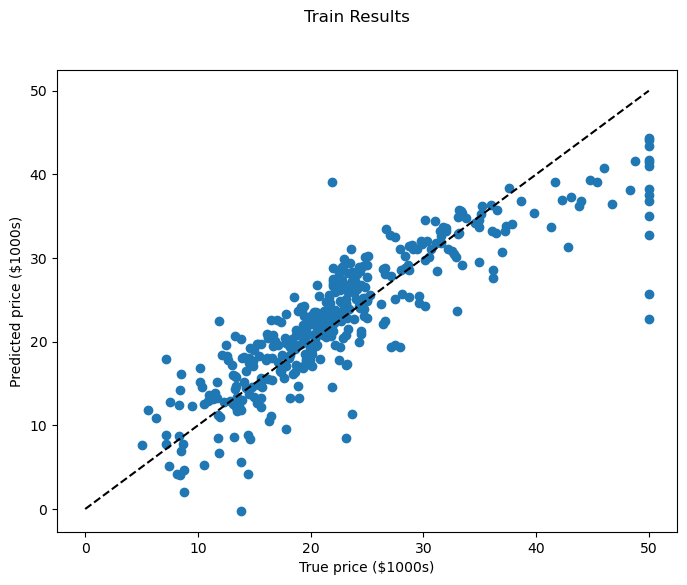

In [139]:
# scatterplot for train results
plt.figure(figsize= (8, 6))
plt.scatter(x=y_train, y= train_preds_LR)
plt.plot([0,50], [0,50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Train Results')
plt.show()

`Figure 2:` A scatterplot of actual vs pred for the LR on the train partition.

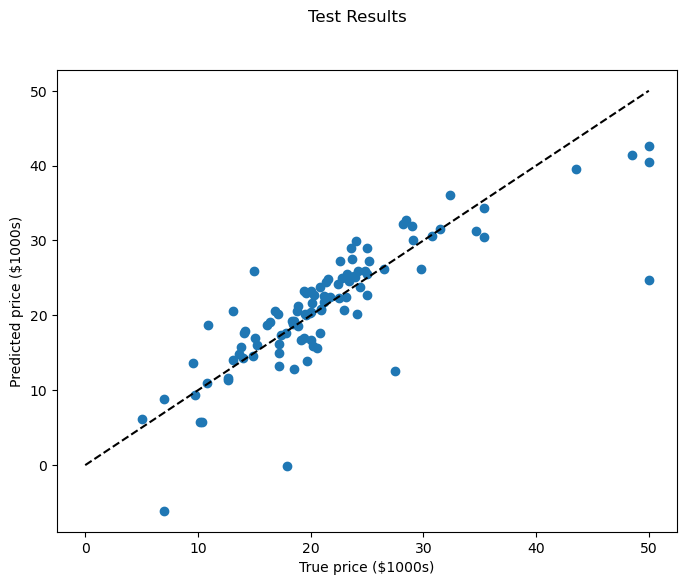

In [140]:
# a quick scatterplot for test results
# same code as above, just different labels
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_preds_LR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Test Results')
plt.show()

**Figure 3:** A scatterplot of actual vs pred for the DTR on test partition.

### DTR Results


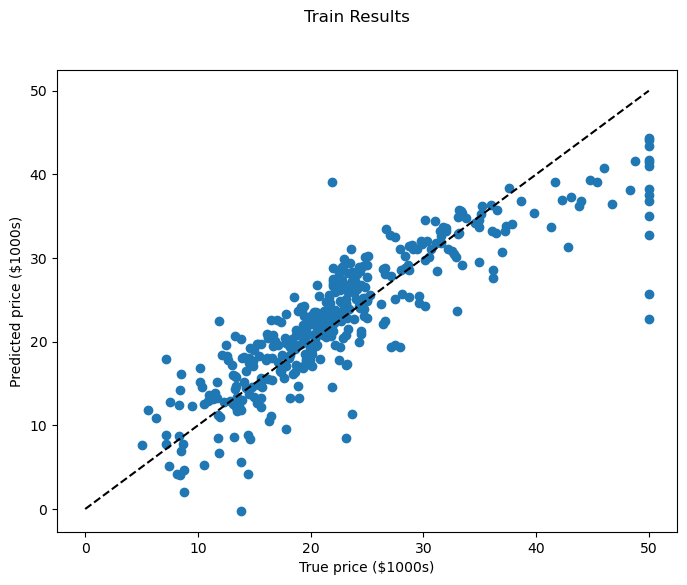

In [141]:
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_train, y=train_preds_LR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Train Results')
plt.show()

**Figure 4:** A scatterplot of actual vs pred for the DTR on train.

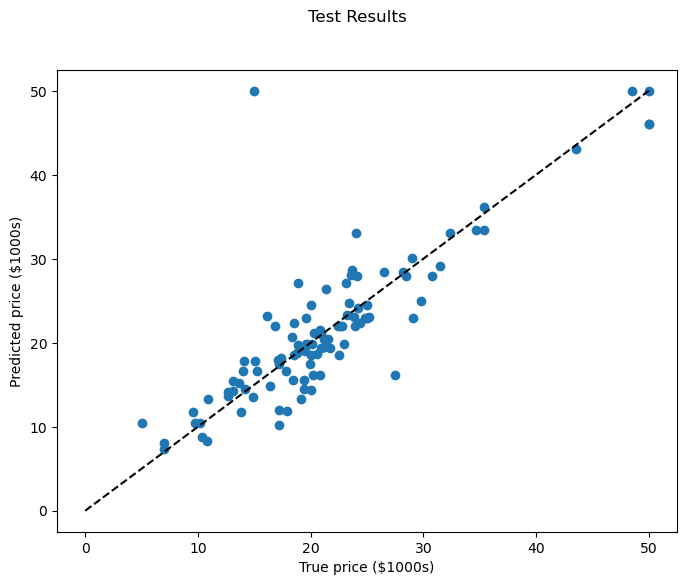

In [142]:
# a quick scatterplot for test results
# same code as above, just different labels
# a quick scatterplot for train results
# let's see how it fit
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_preds_DTR)
plt.plot([0, 50], [0, 50], '--k') # 45 degree line
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.suptitle('Test Results')
plt.show()

**Figure 6:** A scatterplot of actual vs pred for the DTR on test.

### Sub-Plots


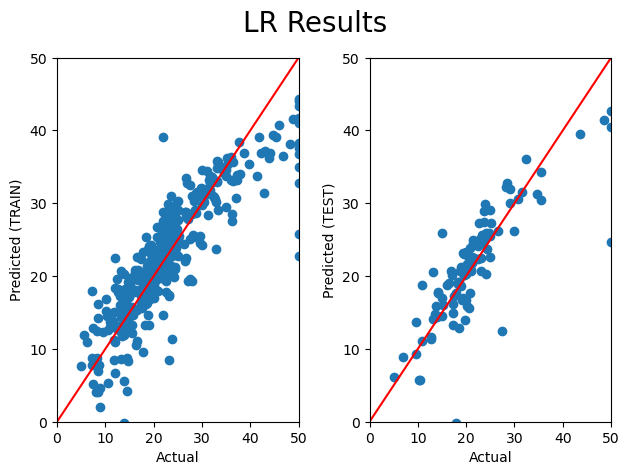

In [143]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("LR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_LR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_LR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 7:** A two-panel scatterplot of actual vs pred for the LR.

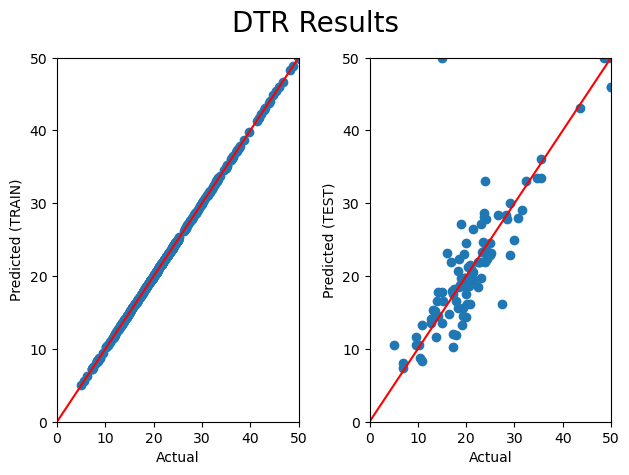

In [144]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("DTR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_DTR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_DTR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 8:** A two-panel scatterplot of actual vs pred for the DTR.

### RFR Results

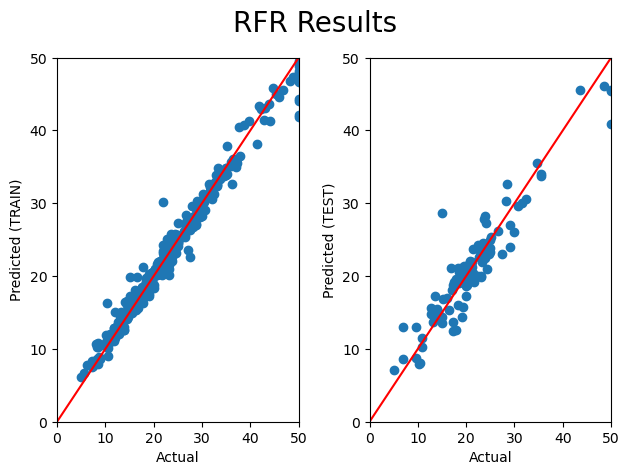

In [145]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("RFR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_RFR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_RFR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()


**Figure 9:** A two-panel scatterplot of actual vs pred for the RFR.

### GBR Results

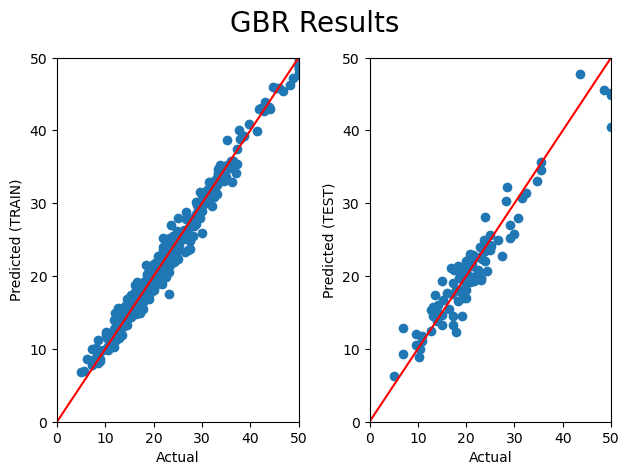

In [146]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("GBR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_GBR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_GBR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 10:** A two-panel scatterplot of actual vs pred for the GBR.